# Primary MERFISH functional annotation and module summaries

This notebook starts from the postprocessed ALDEx result workbook and regenerates the functional annotation / module summary outputs from the original primary MERFISH analysis.

## 0. Setup

Edit `main_dir` and file names here only. The notebook uses sheet names in `aldex_ct_inftss_results.xlsx` as the source of cell type × region strata, 'mygene_annotations.xlsx' for functional annotations generated for original analysis via MyGene module and 'module_dictionary.json' to extract the manually curated annotation → module mapping used in the original workflow.

In [2]:
import os
import re
import json
from glob import glob 
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

from openpyxl.styles import PatternFill, Alignment
from openpyxl.formatting.rule import FormulaRule
from openpyxl.utils import get_column_letter

from matplotlib import pyplot as plt

import kimlabspatial.preprocessing as pp

from scale_aware_st import RepositoryConfig, index_result_tables, load_pooled_strata

# Optional: only needed if re-querying annotations from MyGeneInfo
# pip install mygene, if needed
import mygene

config = RepositoryConfig.from_env()
ALDEX_RESULT_MODE = "published"  # choose "published" or "recompute"
main_dir = config.results_dir / "functional_annotations"
main_dir.mkdir(parents=True, exist_ok=True)
aldex_results_file = main_dir / 'aldex_ct_inftss_results.xlsx'

# Output names reproduced from the original workflow
out_top_go = main_dir / 'cell_type_region_inftss_deg_top_go.xlsx'
out_top_kegg = main_dir / 'cell_type_region_inftss_deg_top_kegg.xlsx'
out_top_geneinfo = main_dir / 'cell_type_region_inftss_deg_top_geneinfo.xlsx'
out_ctregion_all3 = main_dir / 'cell_type_region_inftss_deg_all3_tophits.xlsx'
out_ctregion_mod = main_dir / 'cell_type_region_inftss_deg_kegg_go_mod.xlsx'
out_gene_pivot = main_dir / 'ct_region_inftss_deg_all_pivot_signed.xlsx'
out_celltype_all3 = main_dir / 'cell_type_inftss_deg_all3_tophits.xlsx'
out_region_all3 = main_dir / 'region_inftss_deg_all3_tophits.xlsx'
out_celltype_mod = main_dir / 'cell_type_inftss_deg_go_kegg_mod.xlsx'
out_modules = main_dir / 'cell_type_inftss_deg_modules.xlsx'

MIN_GENES_PER_TERM_CTREGION = 3
MIN_OCCURRENCES_CELLTYPE = 5
MIN_UNIQUE_REGIONS_CELLTYPE = 2
MIN_UNIQUE_GENES_CELLTYPE = 2
MIN_UNIQUE_CELLTYPES_REGION = 2

# Annotation source
# Default: use frozen MyGene-derived annotations generated from the original analysis
# (February 2026). Live MyGene/GO/KEGG outputs may change over time.
RUN_MYGENE = False

annotation_file = (
    config.additional_data_dir / "Additional_File_4.xlsx"
    if ALDEX_RESULT_MODE == "published"
    else main_dir / "mygene_annotations.xlsx"
)
annotation_sheet = "MyGene_Annotations" if ALDEX_RESULT_MODE == "published" else 0

module_file = config.resources_dir / "functional_annotations" / "module_dictionary.json"


## 1. Load postprocessed ALDEx results

Input: `aldex_ct_inftss_results.xlsx`, with one sheet per cell type × region stratum.

In [3]:
def load_aldex_workbook(path):
    """Load postprocessed ALDEx sheets into {ct_region: DataFrame}, indexed by gene."""
    xls = pd.ExcelFile(path)
    results = {}
    for sheet in xls.sheet_names:
        if sheet == 'Not in subset':
            continue
        curr = pd.read_excel(path, sheet_name=sheet)
        curr = curr.loc[:, ~curr.columns.astype(str).str.startswith('Unnamed')]
        if 'gene' not in curr.columns:
            raise ValueError(f"Sheet {sheet!r} does not contain a 'gene' column")
        curr = curr.set_index('gene')
        curr.index.name = None
        results[sheet] = curr
    return results


def split_ct_region(ct_region):
    """Split ct_region key into region and cell_type using the first underscore."""
    region, cell_type = ct_region.split('_', 1)
    return region, cell_type

ct_aldex_results = (
    index_result_tables(
        load_pooled_strata(
            config.additional_data_dir / "Additional_File_4.xlsx",
            sheet_name="Celltype_region_postprocessed",
            stratum_column="Celltype x region",
            gene_column="Gene",
        ),
        gene_column="Gene",
    )
    if ALDEX_RESULT_MODE == "published"
    else load_aldex_workbook(aldex_results_file)
)
ct_regions = list(ct_aldex_results.keys())
unique_regions = sorted({split_ct_region(k)[0] for k in ct_regions})
unique_cell_types = sorted({split_ct_region(k)[1] for k in ct_regions})

print(f'Loaded {len(ct_aldex_results)} ct_region result sheets')
print('Regions:', unique_regions)
print('Cell types:', unique_cell_types)


Loaded 34 ct_region result sheets
Regions: ['Isocortex', 'cerebralnuclei', 'limbicolf', 'nongray', 'thalhyp']
Cell types: ['astro', 'ec', 'ependymal', 'immune', 'olg', 'opc', 'pc', 'vsmc']


## 2. Query gene annotations

This step extracts GO biological process terms and KEGG pathways for each significant gene in each cell type × region stratum from MyGene annotations saved during initial analysis. If RUN_MYGENE flag is set to True (default is False) then it queries MyGeneInfo for GO biological process terms and KEGG pathways for each significant gene in each cell type × region stratum. It also parses the existing `Gene_info` column from the postprocessed ALDEx workbook. 

In [4]:
def _as_list(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    if isinstance(x, list):
        return x
    return [x]


def parse_semicolon_list(value):
    if pd.isna(value) or value == "":
        return []
    return [x.strip() for x in str(value).split(";") if x.strip()]


def parse_gene_info(value):
    if pd.isna(value):
        return []
    return [x.strip() for x in str(value).rstrip(",").split(", ") if x.strip()]


def query_gene_mygene(gene, mg):
    out = {"full_name": None, "summary": None, "go_terms": [], "kegg_paths": []}

    res = mg.query(gene, species="mouse", fields="name,summary,go,pathway")
    hits = res.get("hits", [])
    if not hits:
        return out

    hit = hits[0]

    out["full_name"] = hit.get("name")
    out["summary"] = hit.get("summary")

    go = hit.get("go", {})
    if isinstance(go, dict) and "BP" in go:
        bp_entries = _as_list(go["BP"])
        out["go_terms"] = sorted({
            entry.get("term")
            for entry in bp_entries
            if isinstance(entry, dict) and entry.get("term")
        })

    pathway = hit.get("pathway", {})
    if isinstance(pathway, dict) and "kegg" in pathway:
        kegg_entries = _as_list(pathway["kegg"])
        out["kegg_paths"] = sorted({
            entry.get("name")
            for entry in kegg_entries
            if isinstance(entry, dict) and entry.get("name")
        })

    return out


def load_frozen_annotations(annotation_file, sheet_name=0):
    ann = pd.read_excel(annotation_file, sheet_name=sheet_name)

    ann = ann.set_index("gene")

    frozen = {}
    for gene, row in ann.iterrows():
        frozen[gene] = {
            "full_name": row.get("full_name", None),
            "summary": row.get("summary", None),
            "Gene_info": parse_semicolon_list(row.get("Gene_info", "")),
            "go_terms": parse_semicolon_list(row.get("go_terms", "")),
            "kegg_paths": parse_semicolon_list(row.get("kegg_paths", "")),
        }

    return frozen


def extract_functional_annotations(gene, frozen_annotations):
    return frozen_annotations.get(gene, {
        "full_name": None,
        "summary": None,
        "Gene_info": [],
        "go_terms": [],
        "kegg_paths": [],
    })


def build_ct_aldex_genes(ct_aldex_results, run_mygene=False, annotation_file=None, annotation_sheet=0):
    ct_aldex_genes = {}

    if run_mygene:
        mg = mygene.MyGeneInfo()
        frozen_annotations = None
    else:
        frozen_annotations = load_frozen_annotations(annotation_file, sheet_name=annotation_sheet)

    for ct_region, curr_df in ct_aldex_results.items():
        genes = {}

        for gene in curr_df.index:
            if run_mygene:
                info = query_gene_mygene(gene, mg)
                info["Gene_info"] = (
                    parse_gene_info(curr_df.loc[gene, "Gene_info"])
                    if "Gene_info" in curr_df.columns
                    else []
                )
            else:
                info = extract_functional_annotations(gene, frozen_annotations)

            genes[gene] = info

        ct_aldex_genes[ct_region] = genes

    return ct_aldex_genes


ct_aldex_genes = build_ct_aldex_genes(
    ct_aldex_results,
    run_mygene=RUN_MYGENE,
    annotation_file=annotation_file,
    annotation_sheet=annotation_sheet,
)


## 3. Count annotations within each cell type × region

Outputs in memory: `top_go`, `top_kegg`, `top_gi`.

In [5]:
def count_annotations_by_ct_region(ct_aldex_genes):
    top_go = {}
    top_kegg = {}
    top_gi = {}

    for ct_region, genes in ct_aldex_genes.items():
        go_per_gene = {g: set(genes[g].get('go_terms') or []) for g in genes}
        kegg_per_gene = {g: set(genes[g].get('kegg_paths') or []) for g in genes}
        gi_per_gene = {g: set(genes[g].get('Gene_info') or []) for g in genes}

        go_counts = Counter(t for terms in go_per_gene.values() for t in terms)
        kegg_counts = Counter(p for paths in kegg_per_gene.values() for p in paths)
        gi_counts = Counter(x for infos in gi_per_gene.values() for x in infos)

        top_go[ct_region] = pd.DataFrame(go_counts.items(), columns=['go_term', 'n_genes']).sort_values('n_genes', ascending=False)
        top_kegg[ct_region] = pd.DataFrame(kegg_counts.items(), columns=['kegg_path', 'n_genes']).sort_values('n_genes', ascending=False)
        top_gi[ct_region] = pd.DataFrame(gi_counts.items(), columns=['Gene_info', 'n_genes']).sort_values('n_genes', ascending=False)

    return top_go, top_kegg, top_gi

top_go, top_kegg, top_gi = count_annotations_by_ct_region(ct_aldex_genes)


## 4. Export cell type × region top annotation workbooks

Generates intermediate files (not included in Additional Data):
- `cell_type_region_inftss_deg_top_go.xlsx`
- `cell_type_region_inftss_deg_top_kegg.xlsx`
- `cell_type_region_inftss_deg_top_geneinfo.xlsx`
- `cell_type_region_inftss_deg_all3_tophits.xlsx`

In [6]:
def genes_for_term(ct_region, term, ct_aldex_genes):
    genes = []
    for g, info in ct_aldex_genes[ct_region].items():
        terms = (
            (info.get('go_terms') or []) +
            (info.get('kegg_paths') or []) +
            (info.get('Gene_info') or [])
        )
        if term in terms:
            genes.append(g)
    return genes


def add_gene_names_column(df, ct_region, ct_aldex_genes, ct_aldex_results, term_col=None):
    df = df.copy()
    if term_col is None:
        term_col = df.columns[0]
    df['gene_names'] = df[term_col].map(
        lambda term: ', '.join(
            f"{g}(+)" if ct_aldex_results[ct_region].loc[g, 'age_binary:est'] > 0 else f"{g}(-)"
            for g in genes_for_term(ct_region, term, ct_aldex_genes)
        )
    )
    return df


def write_with_formatting(filepath, dfs_dict, ct_aldex_genes, ct_aldex_results, is_gi=False):
    with pd.ExcelWriter(filepath, engine='openpyxl') as writer:
        for ct_region, df in dfs_dict.items():
            if df is None or df.empty:
                continue
            out = add_gene_names_column(df, ct_region, ct_aldex_genes, ct_aldex_results)
            if is_gi:
                out = out[out['Gene_info'] != 'Y']
            out.to_excel(writer, sheet_name=ct_region, index=False)
            ws = writer.sheets[ct_region]

            headers = [c.value for c in ws[1]]
            n_genes_col = headers.index('n_genes') + 1
            max_row = ws.max_row
            max_col = ws.max_column

            fill = PatternFill(start_color='FFF2CC', end_color='FFF2CC', fill_type='solid')
            col_letter = get_column_letter(n_genes_col)
            rule = FormulaRule(formula=[f'${col_letter}2>=3'], fill=fill)
            ws.conditional_formatting.add(f'A2:{get_column_letter(max_col)}{max_row}', rule)

            for col in ws.columns:
                width = max(len(str(cell.value)) for cell in col if cell.value is not None) + 2
                ws.column_dimensions[col[0].column_letter].width = min(width, 80)


def build_ctregion_all3(top_go, top_kegg, top_gi, ct_aldex_genes, ct_aldex_results):
    all3 = {}
    for ct_region in top_go:
        dfs = []
        for df, label, old_col in [
            (top_go[ct_region], 'GO_Term', 'go_term'),
            (top_kegg[ct_region], 'KEGG_Path', 'kegg_path'),
            (top_gi[ct_region], 'Gene_info', 'Gene_info'),
        ]:
            temp = df.copy()
            temp = temp[temp["n_genes"] >= 3]   # optional threshold
            if temp.empty:
                continue
            temp = temp.rename(columns={old_col: 'category'})
            temp.insert(0, 'Functional Annotation', label)
            temp = add_gene_names_column(temp, ct_region, ct_aldex_genes, ct_aldex_results, term_col='category')
            if label == 'Gene_info':
                temp = temp[temp['category'] != 'Y']
            dfs.append(temp[['Functional Annotation', 'category', 'n_genes', 'gene_names']])
        all3[ct_region] = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    return all3

write_with_formatting(out_top_go, top_go, ct_aldex_genes, ct_aldex_results, is_gi=False)
write_with_formatting(out_top_kegg, top_kegg, ct_aldex_genes, ct_aldex_results, is_gi=False)
write_with_formatting(out_top_geneinfo, top_gi, ct_aldex_genes, ct_aldex_results, is_gi=True)

ctregion_all3 = build_ctregion_all3(top_go, top_kegg, top_gi, ct_aldex_genes, ct_aldex_results)
with pd.ExcelWriter(out_ctregion_all3, engine='openpyxl') as writer:
    for sheet, df in ctregion_all3.items():
        if df.empty:
            continue
        df.to_excel(writer, sheet_name=sheet, index=False)
        ws = writer.sheets[sheet]
        for col in ws.columns:
            ws.column_dimensions[col[0].column_letter].width = min(max(len(str(c.value)) for c in col if c.value is not None) + 2, 80)
        for row in ws.iter_rows():
            for cell in row:
                cell.alignment = Alignment(wrap_text=True, vertical='top', horizontal='left')


## 5. Assign modules within each cell type × region

Generates `cell_type_region_inftss_deg_kegg_go_mod.xlsx`.

In [7]:
def assign_module(category, modules):
    matches = [module.replace('_', ' ') for module, terms in modules.items() if any(category in term for term in terms)]
    return ', '.join(matches)


def build_ctregion_module_tables(top_go, top_kegg, ct_aldex_genes, ct_aldex_results, modules, min_genes=3):
    out = {}
    for ct_region in top_go:
        dfs = []

        go_filtered = top_go[ct_region][top_go[ct_region]['n_genes'] >= min_genes].copy()
        if not go_filtered.empty:
            go_filtered.insert(0, 'Functional Annotation', 'GO_Term')
            go_filtered = go_filtered.rename(columns={'go_term': 'category'})
            dfs.append(go_filtered)

        kegg_filtered = top_kegg[ct_region][top_kegg[ct_region]['n_genes'] >= min_genes].copy()
        if not kegg_filtered.empty:
            kegg_filtered.insert(0, 'Functional Annotation', 'KEGG_Path')
            kegg_filtered = kegg_filtered.rename(columns={'kegg_path': 'category'})
            dfs.append(kegg_filtered)

        if not dfs:
            out[ct_region] = pd.DataFrame()
            continue

        combined = pd.concat(dfs, ignore_index=True)
        combined.insert(1, 'Module', combined['category'].map(lambda x: assign_module(x, modules)))
        combined = add_gene_names_column(combined, ct_region, ct_aldex_genes, ct_aldex_results, term_col='category')
        combined = combined.sort_values(['Module', 'n_genes'], ascending=[True, False])
        out[ct_region] = combined[['Functional Annotation', 'Module', 'category', 'n_genes', 'gene_names']]

    return out

with open(module_file) as f:
    module_dict = json.load(f)

modules = module_dict["modules"]

ctregion_module_tables = build_ctregion_module_tables(
    top_go, top_kegg, ct_aldex_genes, ct_aldex_results, modules,
    min_genes=MIN_GENES_PER_TERM_CTREGION
)

with pd.ExcelWriter(out_ctregion_mod, engine='openpyxl') as writer:
    for sheet, df in ctregion_module_tables.items():
        if df.empty:
            continue
        df.to_excel(writer, sheet_name=sheet, index=False)
        ws = writer.sheets[sheet]
        for col in ws.columns:
            ws.column_dimensions[col[0].column_letter].width = min(max(len(str(c.value)) for c in col if c.value is not None) + 2, 80)


## 6. Aggregate annotations across regions within cell type and across cell types within region

Generates the annotation-level aggregation used for:
- `cell_type_inftss_deg_all3_tophits.xlsx`
- `region_inftss_deg_all3_tophits.xlsx`
- `cell_type_inftss_deg_go_kegg_mod.xlsx`

In [8]:
def aggregate_by_celltype(ct_aldex_genes):
    records = []
    cell_types = sorted({split_ct_region(k)[1] for k in ct_aldex_genes})

    for cell_type in cell_types:
        region_keys = [k for k in ct_aldex_genes if split_ct_region(k)[1] == cell_type]
        term_data = {'Gene_info': {}, 'GO_Term': {}, 'KEGG_Path': {}}

        for region_key in region_keys:
            region, _ = split_ct_region(region_key)
            for gene, info in ct_aldex_genes[region_key].items():
                for label, field in [('GO_Term', 'go_terms'), ('KEGG_Path', 'kegg_paths'), ('Gene_info', 'Gene_info')]:
                    for term in info.get(field, []) or []:
                        if term not in term_data[label]:
                            term_data[label][term] = {'regions': [], 'genes': []}
                        term_data[label][term]['regions'].append(region)
                        term_data[label][term]['genes'].append(f'{gene} ({region})')

        for label, curr_dict in term_data.items():
            for term, info in curr_dict.items():
                region_counts = Counter(info['regions'])
                regions_str = ', '.join(f'{r} ({c})' for r, c in region_counts.items())
                genes_str = ', '.join(info['genes'])
                unique_genes = sorted({g.split('(')[0].strip() for g in info['genes']})
                records.append({
                    'cell_type': cell_type,
                    'Functional_Annotation': label,
                    'category': term,
                    'n_occurrences': len(info['genes']),
                    'regions (counts)': regions_str,
                    'n_unique_regions': len(region_counts),
                    'genes (region)': genes_str,
                    'unique_genes': ', '.join(f'{g} ' for g in unique_genes),
                    'n_unique_genes': len(unique_genes),
                })

    out = pd.DataFrame(records).sort_values(['cell_type', 'Functional_Annotation', 'n_occurrences'], ascending=[True, True, False])
    out = out[out['category'] != 'Y'].reset_index(drop=True)
    return out


def aggregate_by_region(ct_aldex_genes):
    records = []
    regions = sorted({split_ct_region(k)[0] for k in ct_aldex_genes})

    for region in regions:
        cell_type_keys = [k for k in ct_aldex_genes if split_ct_region(k)[0] == region]
        term_data = {'Gene_info': {}, 'GO_Term': {}, 'KEGG_Path': {}}

        for ct_key in cell_type_keys:
            _, cell_type = split_ct_region(ct_key)
            for gene, info in ct_aldex_genes[ct_key].items():
                for label, field in [('GO_Term', 'go_terms'), ('KEGG_Path', 'kegg_paths'), ('Gene_info', 'Gene_info')]:
                    for term in info.get(field, []) or []:
                        if term not in term_data[label]:
                            term_data[label][term] = {'cell_types': [], 'genes': []}
                        term_data[label][term]['cell_types'].append(cell_type)
                        term_data[label][term]['genes'].append(f'{gene} ({cell_type})')

        for label, curr_dict in term_data.items():
            for term, info in curr_dict.items():
                cell_type_counts = Counter(info['cell_types'])
                cell_types_str = ', '.join(f'{ct} ({c})' for ct, c in cell_type_counts.items())
                genes_str = ', '.join(info['genes'])
                unique_genes = sorted({g.split('(')[0].strip() for g in info['genes']})
                records.append({
                    'region': region,
                    'Functional_Annotation': label,
                    'category': term,
                    'n_occurrences': len(info['genes']),
                    'cell_types (counts)': cell_types_str,
                    'n_unique_cell_types': len(cell_type_counts),
                    'genes (cell_type)': genes_str,
                    'unique_genes': ', '.join(f'{g} ' for g in unique_genes),
                    'n_unique_genes': len(unique_genes),
                })

    out = pd.DataFrame(records).sort_values(['region', 'Functional_Annotation', 'n_occurrences'], ascending=[True, True, False])
    out = out[out['category'] != 'Y'].reset_index(drop=True)
    return out

celltype_counts = aggregate_by_celltype(ct_aldex_genes)
region_counts = aggregate_by_region(ct_aldex_genes)

ct_counts_ss = celltype_counts[
    (celltype_counts['n_occurrences'] > MIN_OCCURRENCES_CELLTYPE) &
    (celltype_counts['n_unique_regions'] > MIN_UNIQUE_REGIONS_CELLTYPE) &
    (celltype_counts['n_unique_genes'] > MIN_UNIQUE_GENES_CELLTYPE)
].copy().reset_index(drop=True)

r_counts_ss = region_counts[
    (region_counts['n_occurrences'] > MIN_OCCURRENCES_CELLTYPE) &
    (region_counts['n_unique_cell_types'] > MIN_UNIQUE_CELLTYPES_REGION) &
    (region_counts['n_unique_genes'] > MIN_UNIQUE_GENES_CELLTYPE)
].copy().reset_index(drop=True)

ct_counts_ss.insert(2, 'Module', '')
for idx, row in ct_counts_ss.iterrows():
    if row['Functional_Annotation'] == 'Gene_info':
        ct_counts_ss.loc[idx, 'Module'] = 'NA'
    else:
        ct_counts_ss.loc[idx, 'Module'] = assign_module(row['category'], modules)

ct_counts_gk = ct_counts_ss[ct_counts_ss['Functional_Annotation'] != 'Gene_info'].copy().reset_index(drop=True)
ct_counts_gk = ct_counts_gk.sort_values(['cell_type', 'Module', 'n_occurrences'], ascending=[True, True, False])


## 7. Export aggregated annotation workbooks

In [9]:
def write_grouped_workbook(dfs_by_sheet, filepath, wide_cols=None):
    wide_cols = wide_cols or {}
    with pd.ExcelWriter(filepath, engine='openpyxl') as writer:
        for sheet, df in dfs_by_sheet.items():
            if df is None or df.empty:
                continue
            df.to_excel(writer, sheet_name=sheet, index=False)
            ws = writer.sheets[sheet]
            for col in ws.columns:
                ws.column_dimensions[col[0].column_letter].width = 25
            header_map = {cell.value: cell.column_letter for cell in ws[1]}
            for col_name, width in wide_cols.items():
                if col_name in header_map:
                    ws.column_dimensions[header_map[col_name]].width = width
            for row in ws.iter_rows():
                for cell in row:
                    cell.alignment = Alignment(wrap_text=True, vertical='top', horizontal='left')

ct_counts_dict = {'All': ct_counts_ss}
for ct in unique_cell_types:
    curr = ct_counts_ss[ct_counts_ss['cell_type'] == ct].copy()
    if not curr.empty:
        curr = curr.drop(columns=['cell_type'])
    ct_counts_dict[ct] = curr

region_counts_dict = {'All': r_counts_ss}
for region in unique_regions:
    curr = r_counts_ss[r_counts_ss['region'] == region].copy()
    if not curr.empty:
        curr = curr.drop(columns=['region'])
    region_counts_dict[region] = curr

ct_counts_dict_gk = {'All': ct_counts_gk}
for ct in unique_cell_types:
    curr = ct_counts_gk[ct_counts_gk['cell_type'] == ct].copy()
    if not curr.empty:
        curr = curr.drop(columns=['cell_type'])
    ct_counts_dict_gk[ct] = curr

write_grouped_workbook(
    region_counts_dict,
    out_region_all3,
    wide_cols={
        'cell_types (counts)': 60,
        'genes (cell_type)': 100,
        'unique_genes': 50,
        'category': 50,
        'region': 15,
        'n_occurrences': 15,
        'n_unique_cell_types': 20,
    },
)

write_grouped_workbook(
    ct_counts_dict,
    out_celltype_all3,
    wide_cols={
        'regions (counts)': 60,
        'genes (region)': 100,
        'unique_genes': 50,
        'category': 50,
        'cell_type': 15,
        'n_occurrences': 15,
        'n_unique_regions': 20,
    },
)


## 8. Occurrence-based module summaries from the original workflow

This generates a summary document: `cell_type_inftss_deg_modules.xlsx` style summary.

In [10]:
def parse_region_counts(s):
    out = defaultdict(int)
    if pd.isna(s):
        return out
    for part in [p.strip() for p in str(s).split(',')]:
        m = re.match(r'(.+?) \((\d+)\)', part)
        if m:
            out[m.group(1)] += int(m.group(2))
    return out


def parse_gene_regions(s):
    region_genes = defaultdict(set)
    gene_list = []
    if pd.isna(s):
        return region_genes, gene_list
    for part in [p.strip() for p in str(s).split(',')]:
        m = re.match(r'(.+?) \((.+?)\)', part)
        if m:
            gene = m.group(1).strip()
            region = m.group(2).strip()
            region_genes[region].add(gene)
            gene_list.append(gene)
    return region_genes, gene_list


def build_module_summary(ct_counts_gk):
    grouped = []

    for (cell_type, module), sub in ct_counts_gk.groupby(['cell_type', 'Module']):
        row = {'cell_type': cell_type, 'Module': module}

        row['top_3_terms'] = '\n'.join(
            sub.sort_values('n_occurrences', ascending=False).head(3)['category'].tolist()
        ).replace('\n ', '\n')

        row['n_occurrences_sum'] = sub['n_occurrences'].sum()

        region_term_counts = defaultdict(int)
        for s in sub['regions (counts)']:
            for region, count in parse_region_counts(s).items():
                region_term_counts[region] += count
        row['region_term_counts'] = ', '.join(
            f'{r} ({c})' for r, c in sorted(region_term_counts.items(), key=lambda x: x[1], reverse=True)
        )

        region_genes_total = defaultdict(set)
        gene_sig_counter = Counter()
        for s in sub['genes (region)']:
            region_genes, gene_list = parse_gene_regions(s)
            for region, genes in region_genes.items():
                region_genes_total[region].update(genes)
            gene_sig_counter.update(gene_list)

        for region, genes in region_genes_total.items():
            row[f'{region}_genes'] = ', '.join(sorted(genes))

        row['gene_sig_occurrence'] = ', '.join(
            f'{g} ({c})' for g, c in sorted(gene_sig_counter.items(), key=lambda x: x[1], reverse=True)
        )

        gene_term_counter = Counter()
        for genes in sub['unique_genes']:
            if pd.notna(genes):
                gene_list = [g.strip() for g in str(genes).split(',') if g.strip()]
                gene_term_counter.update(set(gene_list))

        row['gene_term_occurrence'] = ', '.join(
            f'{g} ({c})' for g, c in sorted(gene_term_counter.items(), key=lambda x: x[1], reverse=True)
        )

        row['n_unique_genes'] = len(gene_sig_counter.keys())
        grouped.append(row)

    summary_df = pd.DataFrame(grouped)
    summary_df = summary_df.sort_values(['cell_type', 'n_occurrences_sum'], ascending=[True, False]).reset_index(drop=True)
    return summary_df

summary_df = build_module_summary(ct_counts_gk)

# In the existing output, the module summary appears both as its own workbook and as a leading sheet in cell_type_inftss_deg_go_kegg_mod.xlsx.
write_grouped_workbook({'All': summary_df}, out_modules, wide_cols={'cell_type': 20, 'n_occurrences_sum': 20, 'n_unique_genes': 20})

with pd.ExcelWriter(out_celltype_mod, engine='openpyxl') as writer:
    summary_df.to_excel(writer, sheet_name='Module', index=False)
    for sheet, df in ct_counts_dict_gk.items():
        if df is None or df.empty:
            continue
        df.to_excel(writer, sheet_name=sheet, index=False)

    for sheet_name in writer.sheets:
        ws = writer.sheets[sheet_name]
        for col in ws.columns:
            ws.column_dimensions[col[0].column_letter].width = 25
        for row in ws.iter_rows():
            for cell in row:
                cell.alignment = Alignment(wrap_text=True, vertical='top', horizontal='left')


## 9. Weighted gene-term and module scores

This section applies the scoring scheme used for module-level summaries. Each significant gene is assigned a total contribution proportional to the number of regions in which it appears within a cell type. That contribution is distributed across the gene’s associated GO/KEGG annotations, then summed within functional modules.

In [11]:
def parse_gene_region_sets(value):
    """Parse strings like 'Cd9 (Isocortex), Fgfr3 (thalhyp)' into gene -> set(regions)."""
    gene_regions = defaultdict(set)

    if pd.isna(value):
        return gene_regions

    pairs = re.findall(r'([A-Za-z0-9.\-]+)\s*\(([^)]+)\)', str(value))
    for gene, region in pairs:
        gene_regions[gene.strip()].add(region.strip())

    return gene_regions


def build_gene_term_scores(ct_counts_gk):
    """Build gene-term-level weighted scores from cell-type aggregated GO/KEGG module table."""
    rows = []

    for _, row in ct_counts_gk.iterrows():
        gene_region_map = parse_gene_region_sets(row["genes (region)"])

        for gene, regions in gene_region_map.items():
            rows.append({
                "cell_type": row["cell_type"],
                "gene": gene,
                "term": row["category"],
                "module": row["Module"],
                "n_regions_gene": len(regions),
            })

    df_gene = pd.DataFrame(rows).drop_duplicates()

    df_gene["n_terms_gene"] = (
        df_gene
        .groupby(["cell_type", "gene"])["term"]
        .transform("nunique")
    )

    df_gene["gene_term_score"] = (
        df_gene["n_regions_gene"] / df_gene["n_terms_gene"]
    )

    return df_gene


def build_term_and_module_scores(df_gene):
    """Aggregate gene-term scores to term-level and module-level summaries."""
    term_scores = (
        df_gene
        .groupby(["cell_type", "term", "module"], as_index=False)["gene_term_score"]
        .sum()
        .sort_values(["cell_type", "module", "gene_term_score"], ascending=[True, True, False])
    )

    module_scores = (
        df_gene
        .groupby(["cell_type", "module"], as_index=False)["gene_term_score"]
        .sum()
        .sort_values(["cell_type", "gene_term_score"], ascending=[True, False])
    )

    return term_scores, module_scores


df_gene = build_gene_term_scores(ct_counts_gk)
term_scores, module_scores = build_term_and_module_scores(df_gene)

df_gene.to_excel(main_dir / "gene_term_scores.xlsx", index=False)
term_scores.to_excel(main_dir / "term_scores.xlsx", index=False)
module_scores.to_excel(main_dir / "module_scores.xlsx", index=False)

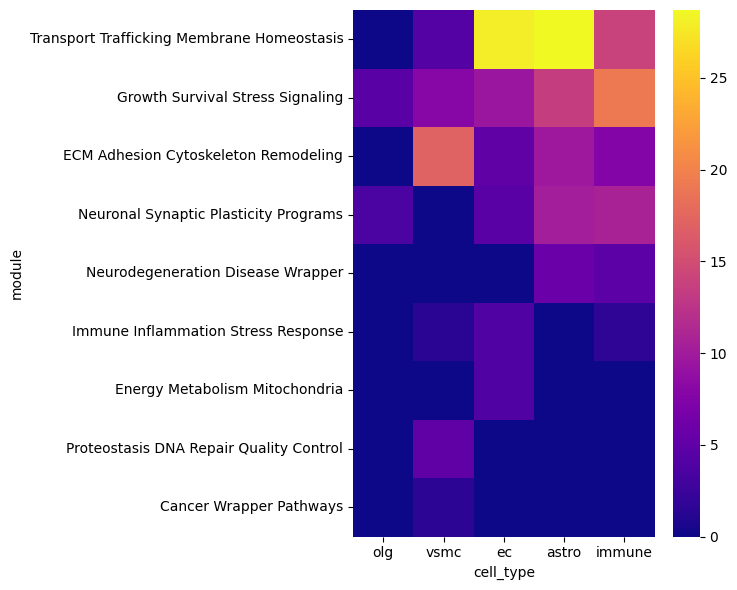

In [12]:
#code to generate Fig 5A

ct_order = ["olg", "vsmc", "ec", "astro", "immune"]

mod_order = [
    "Transport Trafficking Membrane Homeostasis",
    "Growth Survival Stress Signaling",
    "ECM Adhesion Cytoskeleton Remodeling",
    "Neuronal Synaptic Plasticity Programs",
    "Neurodegeneration Disease Wrapper",
    "Immune Inflammation Stress Response",
    "Energy Metabolism Mitochondria",
    "Proteostasis DNA Repair Quality Control",
    "Cancer Wrapper Pathways",
]

mat = (
    module_scores
    .pivot(index="module", columns="cell_type", values="gene_term_score")
    .reindex(index=mod_order, columns=ct_order)
    .fillna(0)
)

plt.figure(figsize=(7.5, 6))
sns.heatmap(mat, cmap="plasma")
plt.tight_layout()
plt.show()